In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../datasets/heart.csv")

In [3]:
df.shape

(918, 12)

In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [10]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [11]:
# Check unique values in text columns
text_cols = ['Sex', 'ChestPainType', 
             'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in text_cols:
    print(f"{col}: {df[col].unique()}")

Sex: ['M' 'F']
ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
RestingECG: ['Normal' 'ST' 'LVH']
ExerciseAngina: ['N' 'Y']
ST_Slope: ['Up' 'Flat' 'Down']


In [12]:
zero_cols = ['RestingBP', 'Cholesterol']
print("Zero Values:")
for col in zero_cols:
    zeros = (df[col] == 0).sum()
    pct = (zeros/len(df))*100
    print(f"{col}: {zeros} zeros ({pct:.1f}%)")

Zero Values:
RestingBP: 1 zeros (0.1%)
Cholesterol: 172 zeros (18.7%)


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
print(df['HeartDisease'].value_counts())

HeartDisease
1    508
0    410
Name: count, dtype: int64


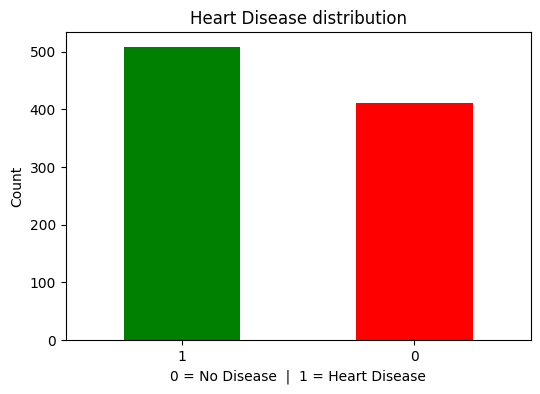

In [15]:
plt.figure(figsize=(6,4))
df['HeartDisease'].value_counts().plot(kind='bar',color=['green','red'])
plt.title('Heart Disease distribution')
plt.xlabel("0 = No Disease  |  1 = Heart Disease")
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

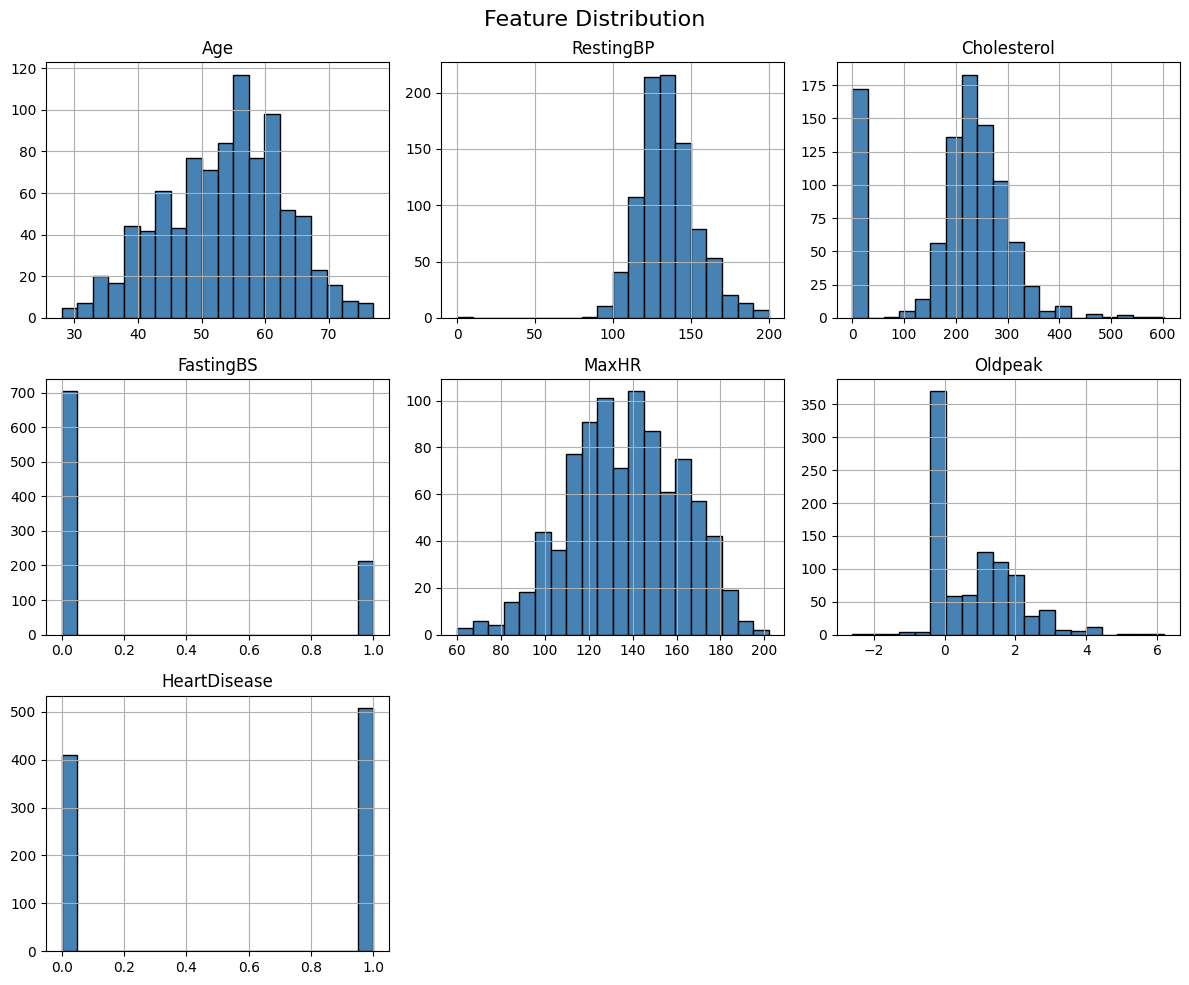

In [16]:
df_num=df.select_dtypes(include=['int64','float64'])
df_num.hist(figsize=(12,10),bins=20,color='steelblue',edgecolor='black')
plt.suptitle('Feature Distribution', fontsize=16)
plt.tight_layout()
plt.show()


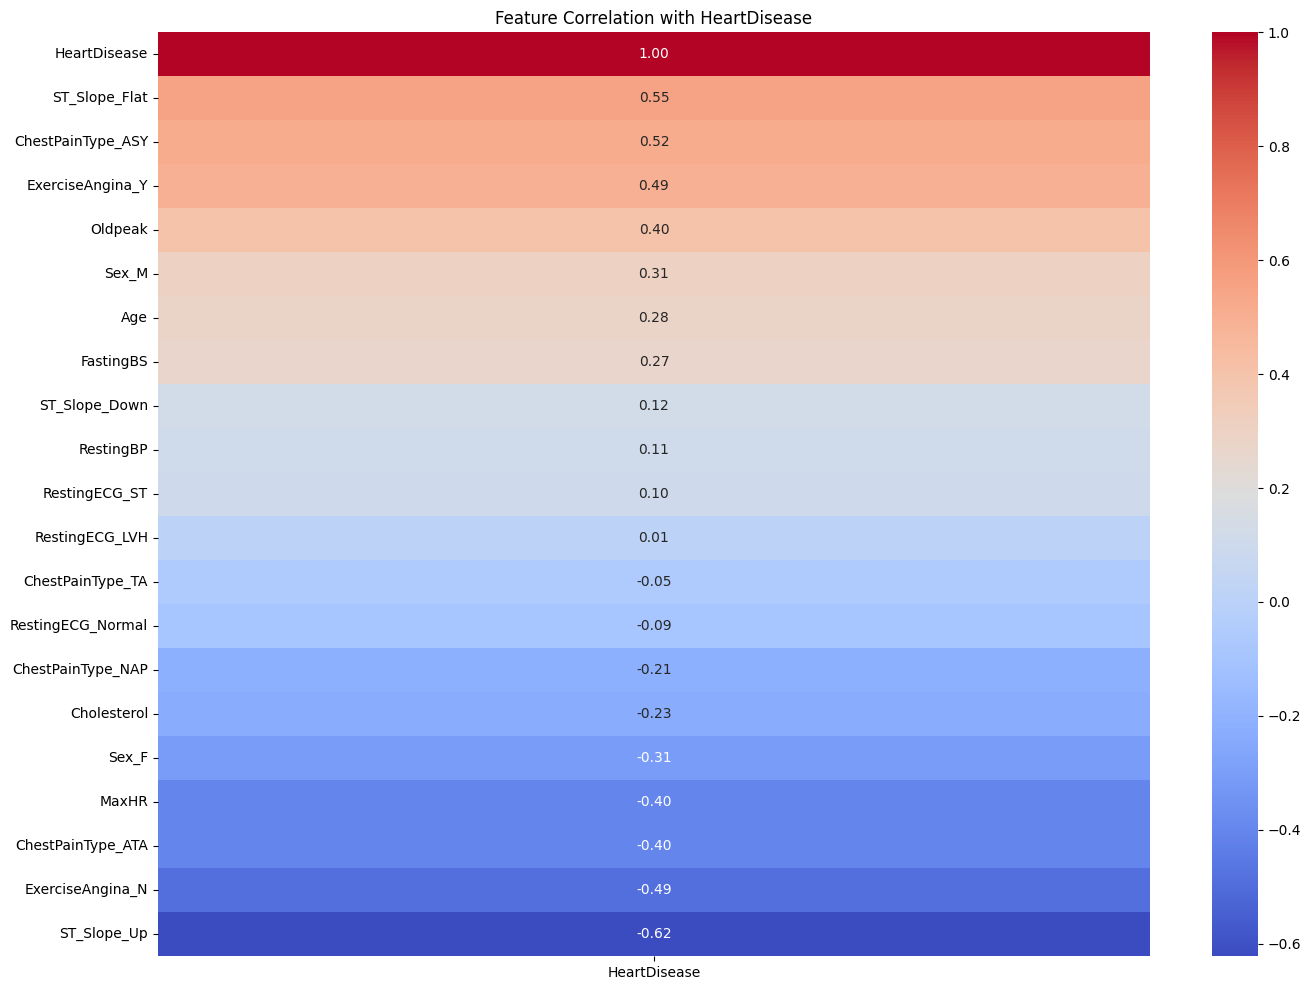

In [17]:
# Encode text columns for heatmap
df_encoded = pd.get_dummies(df)
plt.figure(figsize=(16,12))
sns.heatmap(df_encoded.corr()[['HeartDisease']].sort_values(
            by='HeartDisease', ascending=False),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation with HeartDisease')
plt.show()

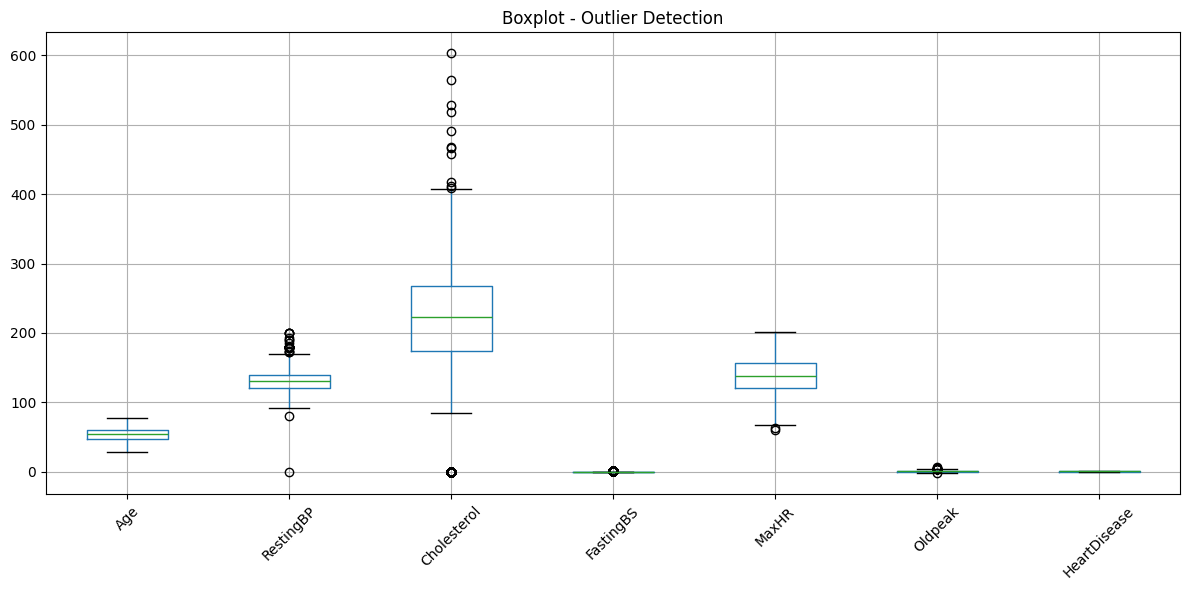

In [18]:
# Boxplot numeric only
plt.figure(figsize=(12,6))
df_num.boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot - Outlier Detection')
plt.tight_layout()
plt.show()

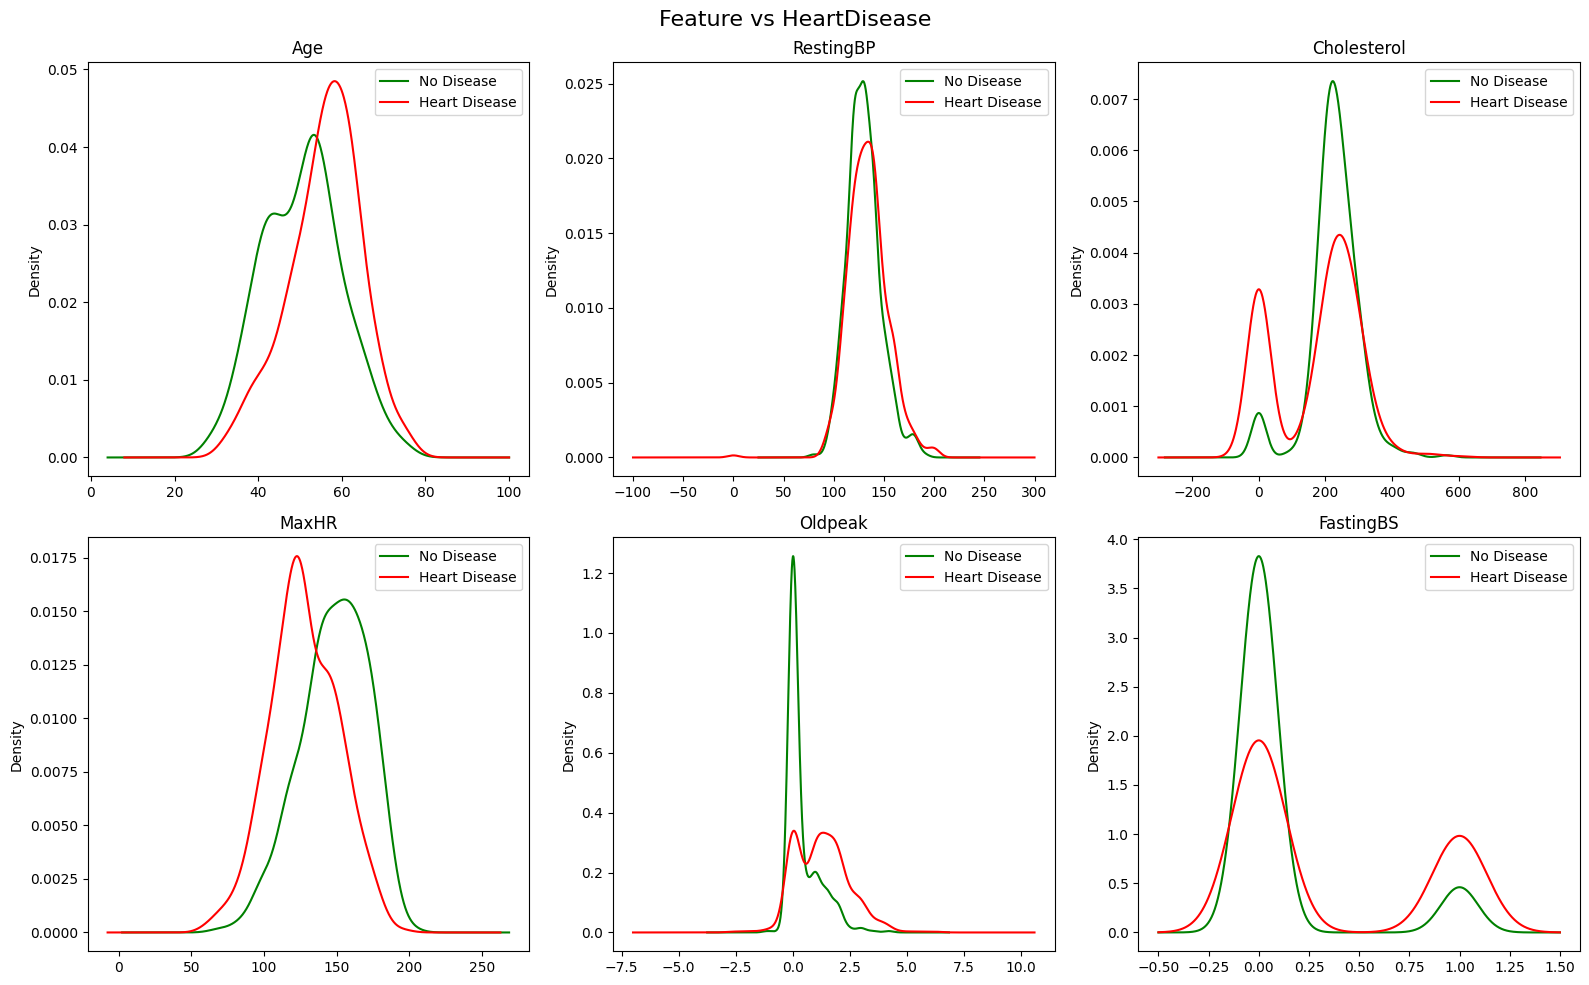

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features = ['Age', 'RestingBP', 'Cholesterol',
            'MaxHR', 'Oldpeak', 'FastingBS']

for i, feature in enumerate(features):
    ax = axes[i//3, i%3]
    df[df['HeartDisease']==0][feature].plot(kind='kde', ax=ax,
                                label='No Disease', color='green')
    df[df['HeartDisease']==1][feature].plot(kind='kde', ax=ax,
                                label='Heart Disease', color='red')
    ax.set_title(feature)
    ax.legend()

plt.suptitle('Feature vs HeartDisease', fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
# Replace zeros with median
zero_cols = ['RestingBP', 'Cholesterol']

for col in zero_cols:
    median_val = df[col].median()
    df[col] = df[col].replace(0, median_val)
    print(f"{col} → zeros replaced with median: {median_val}")

RestingBP → zeros replaced with median: 130.0
Cholesterol → zeros replaced with median: 223.0


In [21]:
df['Sex']=df['Sex'].map({'M': 1 , 'F':0})
df['ExerciseAngina']=df['ExerciseAngina'].map({'Y':1,'N':0})
print("Label Encoding done!")
print(df[['Sex', 'ExerciseAngina']].head())


Label Encoding done!
   Sex  ExerciseAngina
0    1               0
1    0               0
2    1               0
3    0               1
4    1               0


In [22]:

# One Hot Encoding for multi-value columns
df = pd.get_dummies(df, columns=['ChestPainType', 
                                  'RestingECG', 
                                  'ST_Slope'])

# Convert boolean columns to integer (0 and 1)
df = df.astype({col: 'int64' for col in df.select_dtypes('bool').columns})

print("One Hot Encoding done!")
print("New shape:", df.shape)
print("Data types:")
print(df.dtypes)

One Hot Encoding done!
New shape: (918, 19)
Data types:
Age                    int64
Sex                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
ExerciseAngina         int64
Oldpeak              float64
HeartDisease           int64
ChestPainType_ASY      int64
ChestPainType_ATA      int64
ChestPainType_NAP      int64
ChestPainType_TA       int64
RestingECG_LVH         int64
RestingECG_Normal      int64
RestingECG_ST          int64
ST_Slope_Down          int64
ST_Slope_Flat          int64
ST_Slope_Up            int64
dtype: object


In [23]:
# Before scaling — add this after One Hot Encoding
df = df.fillna(df.median())
print("NaN values after fix:", df.isnull().sum().sum())

NaN values after fix: 0


In [24]:
print(df.dtypes)
print("\nAny text columns remaining?")
print(df.select_dtypes(include='object').columns.tolist())

Age                    int64
Sex                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
ExerciseAngina         int64
Oldpeak              float64
HeartDisease           int64
ChestPainType_ASY      int64
ChestPainType_ATA      int64
ChestPainType_NAP      int64
ChestPainType_TA       int64
RestingECG_LVH         int64
RestingECG_Normal      int64
RestingECG_ST          int64
ST_Slope_Down          int64
ST_Slope_Flat          int64
ST_Slope_Up            int64
dtype: object

Any text columns remaining?
[]


In [25]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (918, 18)
y shape: (918,)


In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(734, 18)
(184, 18)


In [27]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
print("Scaling complete!")


Scaling complete!


In [28]:
# Check for NaN values
print("NaN values:")
print(pd.DataFrame(X_train).isnull().sum().sum())

# Check for infinity values
import numpy as np
print("Infinity values:")
print(np.isinf(X_train).sum().sum())

NaN values:
0
Infinity values:
0


In [29]:
import joblib, os
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/heart_scaler.pkl')
print("Heart scaler saved!")

print("\nAll files in models folder:")
print(os.listdir('../models'))

Heart scaler saved!

All files in models folder:
['cancer_model.pkl', 'cancer_scaler.pkl', 'diabetes_model.pkl', 'diabetes_scaler.pkl', 'heart_scaler.pkl']


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score,confusion_matrix

import joblib , os

In [41]:
models={
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True,random_state=42),
    'XGBoost': XGBClassifier(random_state=42,eval_metric='logloss')
}

results={}
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:,1]

    acc=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    auc=roc_auc_score(y_test,y_prob)
    results[name]={
        'Accuracy':round(acc*100,2),
        'f1':round(f1,3),
        'ROC-AUC': round(auc,3)
    }
    print(f"{name}:")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  F1 Score : {f1:.3f}")
    print(f"  ROC-AUC  : {auc:.3f}")
    print()



Logistic Regression:
  Accuracy : 85.87%
  F1 Score : 0.874
  ROC-AUC  : 0.926

Random Forest:
  Accuracy : 86.96%
  F1 Score : 0.883
  ROC-AUC  : 0.933

SVM:
  Accuracy : 85.33%
  F1 Score : 0.871
  ROC-AUC  : 0.932

XGBoost:
  Accuracy : 86.41%
  F1 Score : 0.879
  ROC-AUC  : 0.930



Best Model: Random Forest


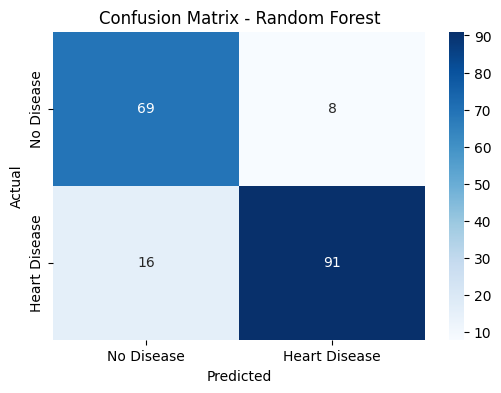

In [38]:
best_name = max(results, key=lambda x: results[x]['Accuracy'])
print("Best Model:", best_name)

best_model = models[best_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Heart Disease'],
            yticklabels=['No Disease','Heart Disease'])
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [39]:
joblib.dump(best_model, '../models/heart_model.pkl')
print("✅ Heart model saved!")
print(os.listdir('../models'))

✅ Heart model saved!
['cancer_model.pkl', 'cancer_scaler.pkl', 'diabetes_model.pkl', 'diabetes_scaler.pkl', 'heart_model.pkl', 'heart_scaler.pkl']
